<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bar Charts**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be provided to you in the form of an RDBMS.

You will use SQL queries to extract the necessary data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data

-   Visualize the relationship between two features

-   Visualize the composition of data

-   Visualize comparison of data


## Setup: Working with the Database
**Install the needed libraries**


In [1]:
!pip install pandas

In [2]:
!pip install matplotlib

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


--2026-01-12 14:00:06--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  56.1MB/s    in 2.7s    

2026-01-12 14:00:09 (56.1 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Distributions


##### 1. Histogram of `ConvertedCompYearly`


Visualize the distribution of yearly compensation (`ConvertedCompYearly`) using a histogram.



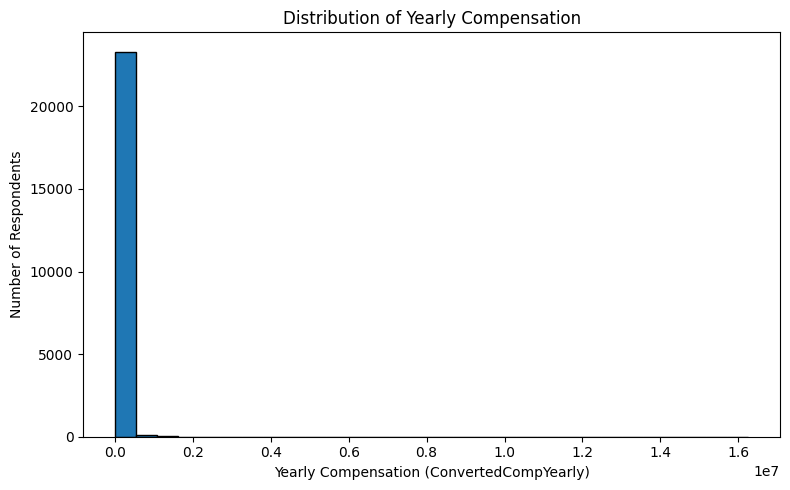

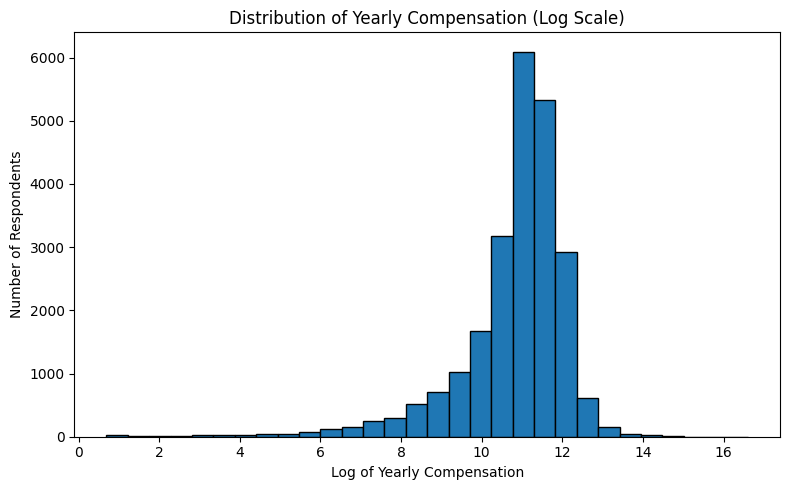

In [4]:
## Write your code here
# Select compensation column and drop missing values
comp_df = df['ConvertedCompYearly'].dropna()
## Histogram (Standard Scale)
plt.figure(figsize=(8, 5))

plt.hist(
    comp_df,
    bins=30,
    edgecolor='black'
)

plt.title('Distribution of Yearly Compensation')
plt.xlabel('Yearly Compensation (ConvertedCompYearly)')
plt.ylabel('Number of Respondents')
plt.tight_layout()
plt.show()
##(Recommended) Histogram with Log Scale -Compensation data is usually right-skewed, so a log scale gives better insight.
plt.figure(figsize=(8, 5))

plt.hist(
    np.log1p(comp_df),
    bins=30,
    edgecolor='black'
)

plt.title('Distribution of Yearly Compensation (Log Scale)')
plt.xlabel('Log of Yearly Compensation')
plt.ylabel('Number of Respondents')
plt.tight_layout()
plt.show()
##The distribution of yearly compensation is right-skewed, with most respondents clustered in lower to mid salary ranges and a small number of high-earning outliers.

##### 2. Box Plot of `Age`


Since `Age` is categorical in the dataset, convert it to numerical values for a box plot.



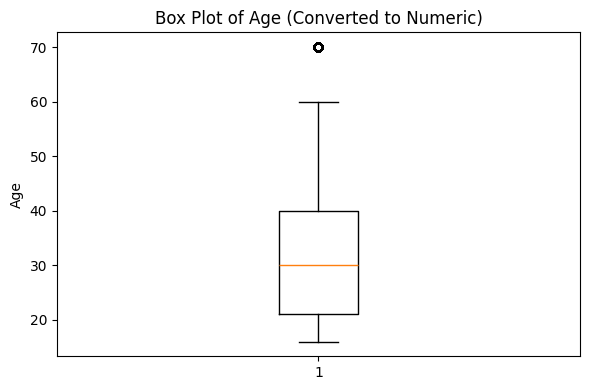

In [5]:
## Write your code here
# Define age mapping (midpoints)
age_map = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}

# Map categorical age to numeric
df['Age_numeric'] = df['Age'].map(age_map)

# Drop missing values
age_numeric = df['Age_numeric'].dropna()
## Create the Box Plot
 
plt.figure(figsize=(6, 4))

plt.boxplot(age_numeric, vert=True)

plt.title('Box Plot of Age (Converted to Numeric)')
plt.ylabel('Age')
plt.tight_layout()
plt.show()
##Because age values are approximated using group midpoints, the box plot provides a relative distribution, not exact ages.

### Task 2: Visualizing Relationships in Data


##### 1. Scatter Plot of `Age_numeric` and `ConvertedCompYearly`


Explore the relationship between age and compensation.



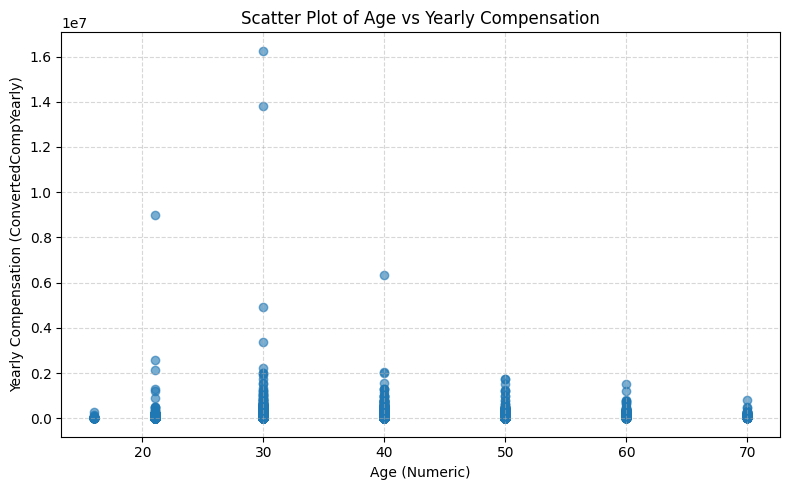

In [6]:
## Write your code here
# Map age groups to numeric midpoints
age_map = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}

df['Age_numeric'] = df['Age'].map(age_map)

# Keep relevant columns and drop missing values
scatter_df = df[['Age_numeric', 'ConvertedCompYearly']].dropna()
## Create the Scatter Plot
 
plt.figure(figsize=(8, 5))

plt.scatter(
    scatter_df['Age_numeric'],
    scatter_df['ConvertedCompYearly'],
    alpha=0.6
)

plt.title('Scatter Plot of Age vs Yearly Compensation')
plt.xlabel('Age (Numeric)')
plt.ylabel('Yearly Compensation (ConvertedCompYearly)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
##Yearly compensation generally increases with age, though salary variability becomes greater in older age groups.

##### 2. Bubble Plot of `ConvertedCompYearly` and `JobSatPoints_6` with `Age_numeric` as Bubble Size


Explore how compensation and job satisfaction are related, with age as the bubble size.


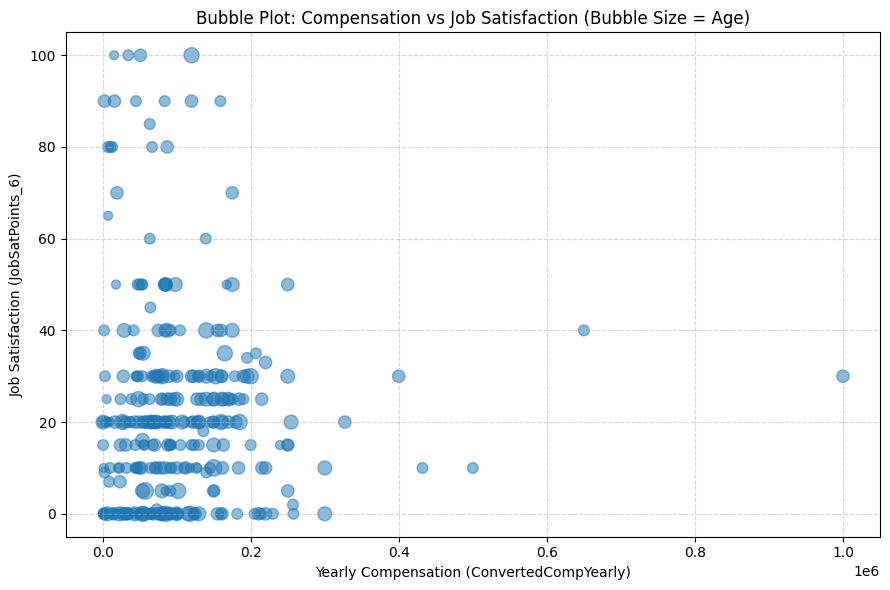

In [8]:
## Write your code here
# Map age groups to numeric midpoints
age_map = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}

df['Age_numeric'] = df['Age'].map(age_map)

# Keep relevant columns and drop missing values
bubble_df = df[['ConvertedCompYearly', 'JobSatPoints_6', 'Age_numeric']].dropna().head(300)
## Create the Bubble Plot
 
plt.figure(figsize=(9, 6))

plt.scatter(
    bubble_df['ConvertedCompYearly'],
    bubble_df['JobSatPoints_6'],
    s=bubble_df['Age_numeric'] * 2,   # scale bubble size
    alpha=0.5
)

plt.title('Bubble Plot: Compensation vs Job Satisfaction (Bubble Size = Age)')
plt.xlabel('Yearly Compensation (ConvertedCompYearly)')
plt.ylabel('Job Satisfaction (JobSatPoints_6)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
##Higher compensation is often associated with higher job satisfaction, while older respondents tend to cluster in higher salary ranges, though satisfaction varies across all ages.

### Task 3: Visualizing Composition of Data with Bar Charts


##### 1. Horizontal Bar Chart of `MainBranch` Distribution


Visualize the distribution of respondents’ primary roles to understand their professional focus.



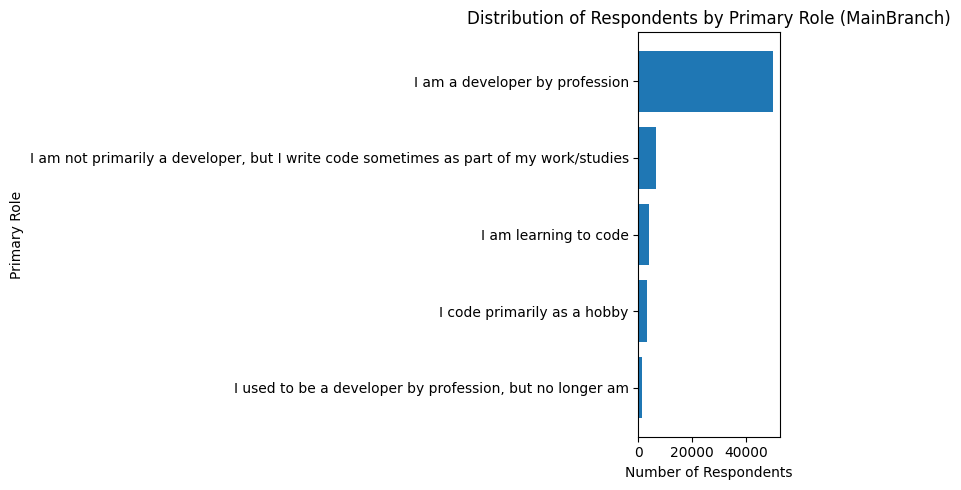

In [9]:
## Write your code here
# Count respondents by primary role
mainbranch_counts = df['MainBranch'].value_counts().sort_values()
plt.figure(figsize=(8, 5))

plt.barh(
    mainbranch_counts.index,
    mainbranch_counts.values
)

plt.title('Distribution of Respondents by Primary Role (MainBranch)')
plt.xlabel('Number of Respondents')
plt.ylabel('Primary Role')
plt.tight_layout()
plt.show()
##Most respondents identify primarily as developers, with fewer participants coming from non-developer or learning-focused roles.

##### 2. Vertical Bar Chart of Top 5 Programming Languages Respondents Want to Work With


Identify the most desired programming languages based on `LanguageWantToWorkWith`.



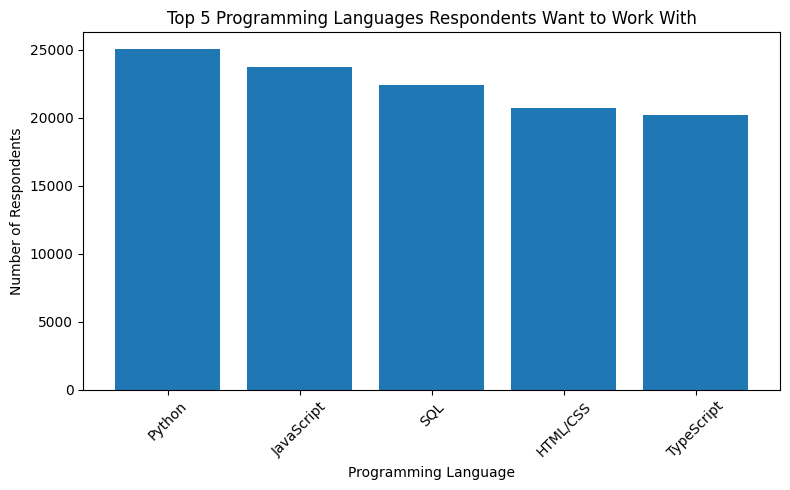

In [10]:
## Write your code here
# Keep relevant column and drop missing values
lang_df = df['LanguageWantToWorkWith'].dropna()

# Split multiple languages into separate rows
lang_df = lang_df.str.split(';').explode()

# Count top 5 desired languages
top_languages = lang_df.value_counts().head(5)
## Create the Vertical Bar Chart
 
plt.figure(figsize=(8, 5))

plt.bar(
    top_languages.index,
    top_languages.values
)

plt.title('Top 5 Programming Languages Respondents Want to Work With')
plt.xlabel('Programming Language')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
##A few widely adopted programming languages dominate developer interest, reflecting current industry demand and career relevance.

##### 3. Stacked Bar Chart of Median `JobSatPoints_6` and `JobSatPoints_7` by Age Group


Compare job satisfaction metrics across different age groups with a stacked bar chart.


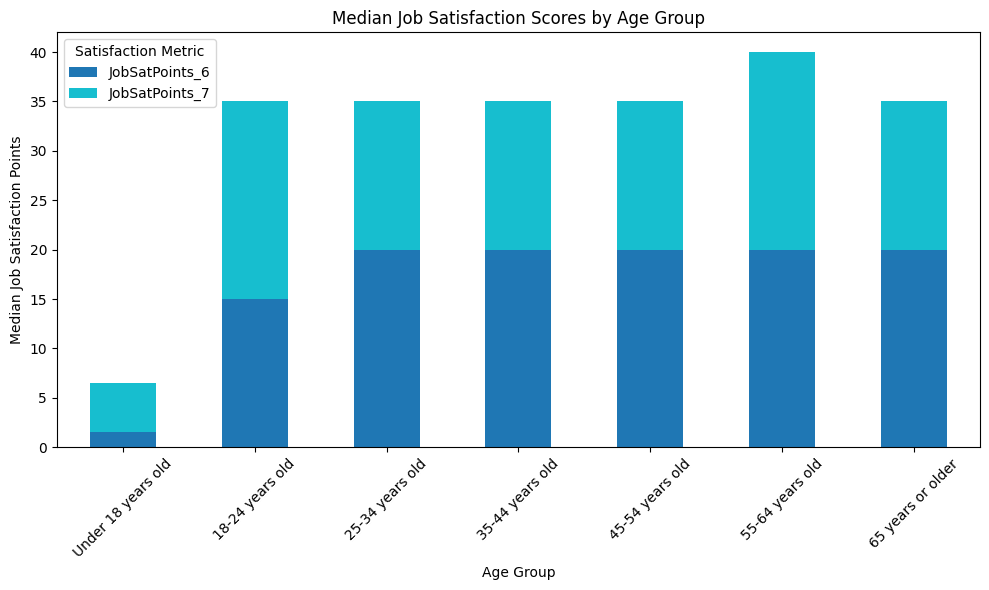

In [11]:
## Write your code here
# Select relevant columns and drop missing values
sat_df = df[['Age', 'JobSatPoints_6', 'JobSatPoints_7']].dropna()

# Define age order for proper sequencing
age_order = [
    'Under 18 years old',
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old',
    '65 years or older'
]

sat_df['Age'] = pd.Categorical(sat_df['Age'], categories=age_order, ordered=True)
## Compute Median Satisfaction Scores by Age Group
 
median_sat = (
    sat_df
    .groupby('Age', observed=True)
    .agg(
        JobSatPoints_6=('JobSatPoints_6', 'median'),
        JobSatPoints_7=('JobSatPoints_7', 'median')
    )
)
## Create the Stacked Bar Chart
 
median_sat.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    colormap='tab10'
)

plt.title('Median Job Satisfaction Scores by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Median Job Satisfaction Points')
plt.legend(title='Satisfaction Metric')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
##Median job satisfaction remains relatively consistent across age groups, with slightly higher values observed in mid-career stages.

##### 4. Bar Chart of Database Popularity (`DatabaseHaveWorkedWith`)


Identify the most commonly used databases among respondents by visualizing `DatabaseHaveWorkedWith`.



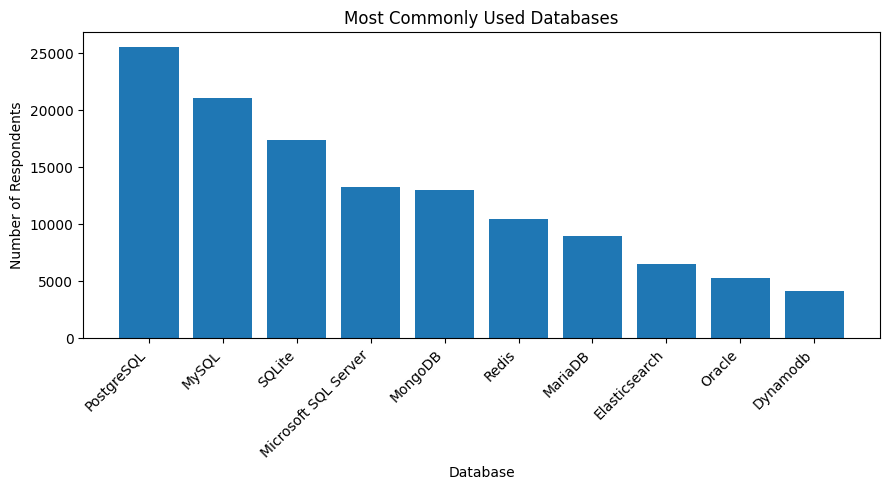

In [13]:
## Write your code here
# Select column and drop missing values
db_df = df['DatabaseHaveWorkedWith'].dropna()

# Split multiple databases into separate rows
db_df = db_df.str.split(';').explode()

# Count database usage
db_counts = db_df.value_counts().head(10)  # top 10 for readability
## Create the Bar Chart
 
plt.figure(figsize=(9, 5))

plt.bar(
    db_counts.index,
    db_counts.values
)

plt.title('Most Commonly Used Databases')
plt.xlabel('Database')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
##A small set of industry-standard databases dominates usage among respondents, indicating strong adoption of mature and widely supported technologies.

### Task 4: Visualizing Comparison of Data with Bar Charts


##### 1. Grouped Bar Chart of Median `ConvertedCompYearly` for Different Age Groups


Compare median compensation across multiple age groups with a grouped bar chart.



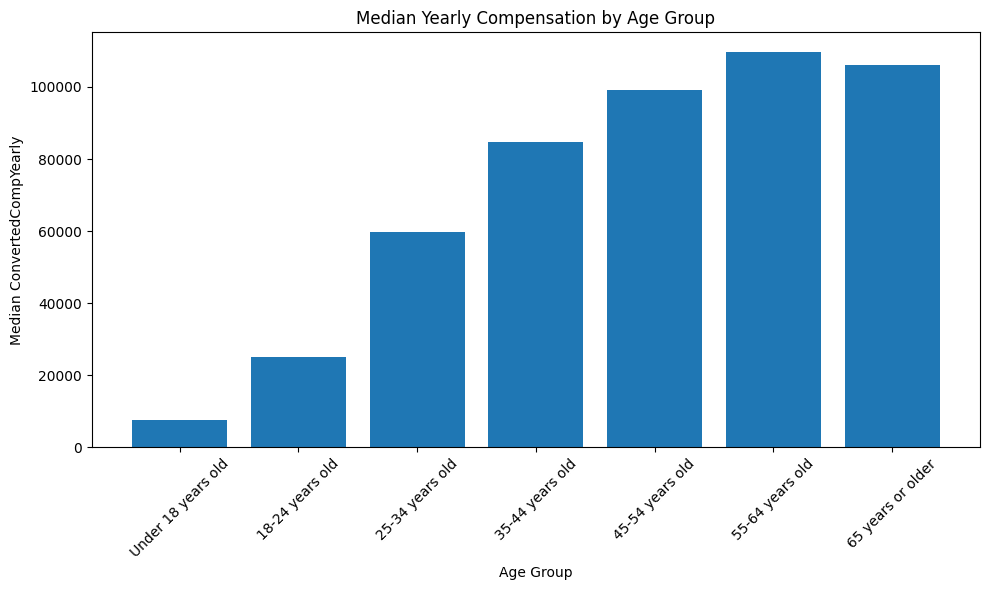

In [14]:
## Write your code here
# Keep relevant columns and drop missing values
comp_df = df[['Age', 'ConvertedCompYearly']].dropna()

# Define proper age order
age_order = [
    'Under 18 years old',
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old',
    '65 years or older'
]

# Convert Age to ordered categorical
comp_df['Age'] = pd.Categorical(comp_df['Age'], categories=age_order, ordered=True)

# Compute median compensation by age group
median_comp = (
    comp_df
    .groupby('Age', observed=True)['ConvertedCompYearly']
    .median()
    .reset_index()
)

median_comp
## Create the Grouped Bar Chart
 
plt.figure(figsize=(10, 6))

plt.bar(
    median_comp['Age'],
    median_comp['ConvertedCompYearly']
)

plt.title('Median Yearly Compensation by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Median ConvertedCompYearly')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
##Median yearly compensation increases with age, peaks in mid-career, and stabilizes or slightly declines in later age groups.

##### 2. Bar Chart of Respondent Count by Country


Show the distribution of respondents by country to see which regions are most represented.



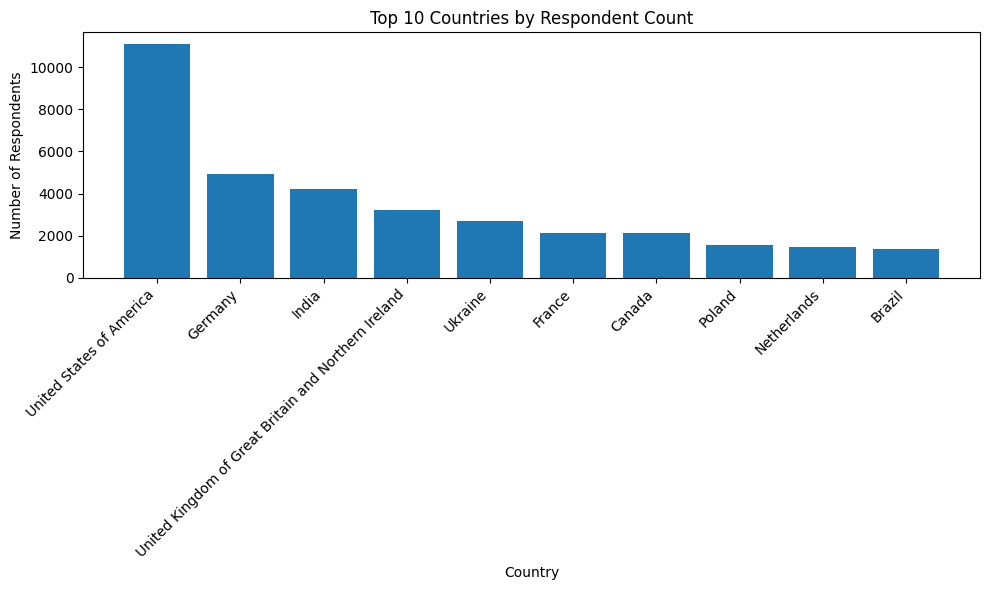

In [15]:
## Write your code here
# Count respondents by country
country_counts = df['Country'].value_counts().head(10)  # top 10 countries
## Create the Bar Chart -Vertical Bar Chart
 
plt.figure(figsize=(10, 6))

plt.bar(
    country_counts.index,
    country_counts.values
)

plt.title('Top 10 Countries by Respondent Count')
plt.xlabel('Country')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
##Survey participation is concentrated in a few countries, with these regions contributing the majority of respondents.

### Final Step: Review


This lab demonstrates how to create and interpret different types of bar charts, allowing you to analyze the composition, comparison, and distribution of categorical data in the Stack Overflow dataset, including main professional branches, programming language preferences, and compensation by age group. Bar charts effectively compare counts and median values across various categories.


## Summary


After completing this lab, you will be able to:
- Create a horizontal bar chart to visualize the distribution of respondents' primary roles, helping to understand their professional focus.
- Develop a vertical bar chart to identify the most desired programming languages based on the LanguageWantToWorkWith variable.
- Use a stacked bar chart to compare job satisfaction metrics across different age groups.
- Create a bar chart to visualize the most commonly used databases among respondents using the DatabaseHaveWorkedWith variable.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
